In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD

from sentence_transformers import SentenceTransformer

In [ ]:
# Load dataset from Excel (3 sheets -> 3 intent classes)
EXCEL_PATH = "/content/drive/MyDrive/final_intent_classifier/finaL_cleaned_intent_classifier_dataset_updated.xlsx"

df_db   = pd.read_excel(EXCEL_PATH, sheet_name="Database Queries")[["Question", "Intent Label"]]
df_plat = pd.read_excel(EXCEL_PATH, sheet_name="Platform Queries")[["Question", "Intent Label"]]
df_gen  = pd.read_excel(EXCEL_PATH, sheet_name="General Queries")[["Question", "Intent Label"]]

# Rename to Intent_Label for consistency in the rest of the notebook
df_db   = df_db.rename(columns={"Intent Label": "Intent_Label"})
df_plat = df_plat.rename(columns={"Intent Label": "Intent_Label"})
df_gen  = df_gen.rename(columns={"Intent Label": "Intent_Label"})

raw_df = pd.concat([df_db, df_plat, df_gen], ignore_index=True)
raw_df.dropna(subset=["Question", "Intent_Label"], inplace=True)
raw_df.reset_index(drop=True, inplace=True)

print(f"Total samples: {len(raw_df)}")
print(raw_df["Intent_Label"].value_counts())

Total samples: 3839
Intent_Label
platform_query    1439
database_query    1200
general_query     1200
Name: count, dtype: int64


In [ ]:
# Encode string labels to integers (same as original target encoding)
category_names = sorted(raw_df["Intent_Label"].unique().tolist())
label2idx = {lbl: i for i, lbl in enumerate(category_names)}

X_raw = raw_df["Question"].tolist()
y_raw = raw_df["Intent_Label"].map(label2idx).tolist()

print("Classes:", category_names)
print("Total samples:", len(X_raw))

Classes: ['database_query', 'general_query', 'platform_query']
Total samples: 3839


In [ ]:
import numpy as np
print("y shape:", np.array(y_raw).shape)

y shape: (3839,)


In [ ]:
print(category_names)

['database_query', 'general_query', 'platform_query']


In [ ]:
print(X_raw[:5])

['What are all the crops available in the database?', 'List all crop names stored in the system.', 'Show me the crop with crop_id equal to 1.', 'When was the crop named "Wheat" created?', 'How many crops are currently registered?']


In [ ]:
# Dataset summary
print(f"Number of samples: {len(X_raw)}")
print(f"Number of classes: {len(category_names)}")
print(f"Classes: {category_names}")

Number of samples: 3839
Number of classes: 3
Classes: ['database_query', 'general_query', 'platform_query']


In [ ]:

def generate_metadata(texts):
    lengths = [len(t) for t in texts]
    word_counts = [len(t.split()) for t in texts]

    avg_word_lengths = []
    uppercase_ratios = []
    digit_ratios = []

    for t in texts:
        words = t.split()
        if words:
            avg_word_lengths.append(np.mean([len(w) for w in words]))
        else:
            avg_word_lengths.append(0)

        denom = max(len(t), 1)

        uppercase_ratios.append(
            sum(1 for c in t if c.isupper()) / denom
        )

        digit_ratios.append(
            sum(1 for c in t if c.isdigit()) / denom
        )

    return pd.DataFrame({
        "text": texts,
        "char_length": lengths,
        "word_count": word_counts,
        "avg_word_length": avg_word_lengths,
        "uppercase_ratio": uppercase_ratios,
        "digit_ratio": digit_ratios
    })

# Calling the function to generate a structured dataset that contains: raw text + metadata
df = generate_metadata(X_raw)
df["target"] = y_raw

df.head()

,text,char_length,word_count,avg_word_length,uppercase_ratio,digit_ratio,target
0,What are all the crops available in the database?,49,9,4.555556,0.020408,0.00000,0
1,List all crop names stored in the system.,41,8,4.250000,0.024390,0.00000,0
2,Show me the crop with crop_id equal to 1.,41,9,3.666667,0.024390,0.02439,0
3,"When was the crop named ""Wheat"" created?",40,7,4.857143,0.050000,0.00000,0
4,How many crops are currently registered?,40,6,5.833333,0.025000,0.00000,0


In [ ]:

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X

,text,char_length,word_count,avg_word_length,uppercase_ratio,digit_ratio
0,What are all the crops available in the database?,49,9,4.555556,0.020408,0.00000
1,List all crop names stored in the system.,41,8,4.250000,0.024390,0.00000
2,Show me the crop with crop_id equal to 1.,41,9,3.666667,0.024390,0.02439
3,"When was the crop named ""Wheat"" created?",40,7,4.857143,0.050000,0.00000
4,How many crops are currently registered?,40,6,5.833333,0.025000,0.00000
...,...,...,...,...,...,...
3834,What is the veil of ignorance?,30,6,4.166667,0.033333,0.00000
3835,What is contractarianism?,25,3,7.666667,0.040000,0.00000
3836,What is natural law theory?,27,5,4.600000,0.037037,0.00000
3837,What is divine command theory?,30,5,5.200000,0.033333,0.00000


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
3834,1
3835,1
3836,1
3837,1


In [ ]:
class EmbeddingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        self.model = SentenceTransformer(self.model_name)
        return self

    def transform(self, X):
        embeddings = self.model.encode(
            X.tolist(),
            show_progress_bar=False
        )
        return np.array(embeddings)

In [ ]:
tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("svd", TruncatedSVD(n_components=300, random_state=42))
])

In [ ]:
tfidf_pipeline

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('svd', TruncatedSVD(n_components=300, random_state=42))])

In [ ]:
embedding_pipeline = Pipeline([
    ("embed", EmbeddingTransformer())
])

In [ ]:
embedding_pipeline

Pipeline(steps=[('embed', EmbeddingTransformer())])

In [ ]:
metadata_features = [
    "char_length",
    "word_count",
    "avg_word_length",
    "uppercase_ratio",
    "digit_ratio"
]

metadata_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf_pipeline, "text"),
        ("embedding", embedding_pipeline, "text"),
        ("metadata", metadata_pipeline, metadata_features),
    ],
    remainder="drop"
)

In [ ]:
full_pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(C=1.0, max_iter=2000))
])

In [ ]:
full_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('tfidf',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_features=5000)),
                                                                  ('svd',
                                                                   TruncatedSVD(n_components=300,
                                                                                random_state=42))]),
                                                  'text'),
                                                 ('embedding',
                                                  Pipeline(steps=[('embed',
                                                                   EmbeddingTransformer())]),
                                                  'text'),
                                                 ('metadata',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['char_length', 'word_count',
                                                   'avg_word_length',
                                                   'uppercase_ratio',
                                                   'digit_ratio'])])),
                ('clf', LinearSVC(max_iter=2000))])

In [ ]:

y_pred = full_pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=category_names))

                precision    recall  f1-score   support

database_query       1.00      0.99      1.00       240
 general_query       0.99      1.00      0.99       240
platform_query       0.99      0.99      0.99       288

      accuracy                           0.99       768
     macro avg       0.99      0.99      0.99       768
  weighted avg       0.99      0.99      0.99       768



/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


                precision    recall  f1-score   support

database_query       1.00      0.99      1.00       240
 general_query       0.99      1.00      0.99       240
platform_query       0.99      0.99      0.99       288

      accuracy                           0.99       768
     macro avg       0.99      0.99      0.99       768
  weighted avg       0.99      0.99      0.99       768



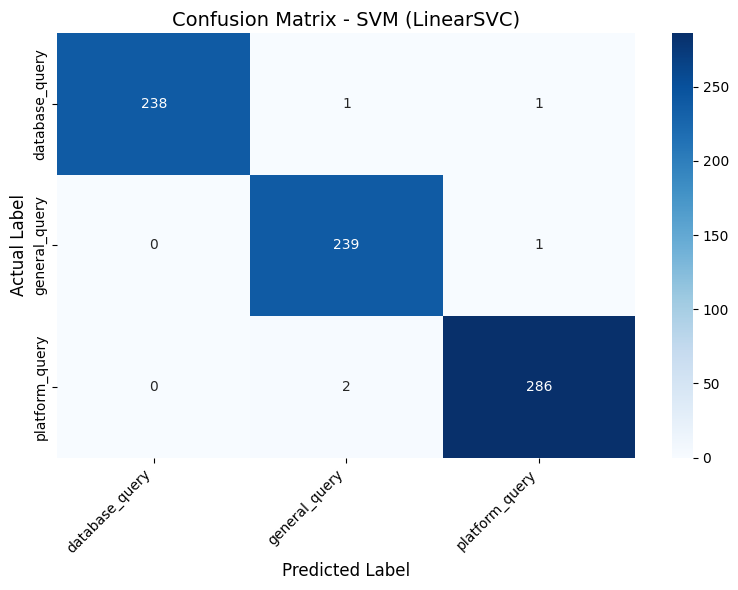

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predictions
y_pred = full_pipeline.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred, target_names=category_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=category_names,
            yticklabels=category_names)

plt.title('Confusion Matrix - SVM (LinearSVC)', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Database Query:
# What are all the crops available in the database?
# Platform Query:
# I forgot my password, how can I reset it?
# General Query:
# What is the speed of light?

In [ ]:
# import pandas as pd
# import numpy as np

# def predict_text(text):
#     sample_df = generate_metadata([text])
#     pred_index = full_pipeline.predict(sample_df)[0]
#     predicted_label = category_names[pred_index]
#     print(f"\n📝 Input     : {text[:100]}{'...' if len(text) > 100 else ''}")
#     print(f"🏷️  Predicted : {predicted_label}\n")
#     print("-" * 60)

# print("=" * 60)
# print("       SVM Intent Classifier - Interactive Tester")
# print("=" * 60)
# print("Categories:", list(category_names))
# print("Type 'quit' to exit\n")

# while True:
#     user_input = input("Enter your text: ")
#     if user_input.lower() == "quit":
#         print("Exiting. Bye!")
#         break
#     if user_input.strip() == "":
#         print("Please enter some text!")
#         continue
#     predict_text(user_input)


In [ ]:
import pickle

# Save the model
with open("27_march_svm_intent_classifier.pkl", "wb") as f:
    pickle.dump(full_pipeline, f)

print("Model saved as 27_march__svm_intent_classifier.pkl")

Model saved as 27_march__svm_intent_classifier.pkl


In [ ]:
import pandas as pd
import numpy as np

def predict_text(text):
    sample_df = generate_metadata([text])
    pred_index = full_pipeline.predict(sample_df)[0]
    predicted_label = category_names[pred_index]
    print(f"\n📝 Input     : {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"🏷️  Predicted : {predicted_label}\n")
    print("-" * 60)

print("=" * 60)
print("       SVM Intent Classifier - Interactive Tester")
print("=" * 60)
print("Categories:", list(category_names))
print("Type 'quit' to exit\n")

while True:
    user_input = input("Enter your text: ")
    if user_input.lower() == "quit":
        print("Exiting. Bye!")
        break
    if user_input.strip() == "":
        print("Please enter some text!")
        continue
    predict_text(user_input)

       SVM Intent Classifier - Interactive Tester
Categories: ['database_query', 'general_query', 'platform_query']
Type 'quit' to exit

Enter your text: What is training feature set ?


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



📝 Input     : What is training feature set ?
🏷️  Predicted : platform_query

------------------------------------------------------------
